**Linear Regression** :

**Y = wX + b**   (i.e. y = mx + c)

Y -> Dependent variable

X -> Independent variable

w -> weight

b -> bias


---



**Gradient Descent** :

An optimization algorithm used for minimizing the loss function in various machine learning algorithms. It is used for updaing the parameters of the learning model.

formulae to update the weights:

w = w - a * dw

b = b - a * db


---



**Learning rate** :

Its a tuning parameter in an optimization algorithm that determines the step size at each iteration while moving towards a minimum of a loss function.


---



Weight & bias are model parameters and learning rate & no.of iterations are hyperparameters.

No.of iteration means how many times the model will go through the data.


---



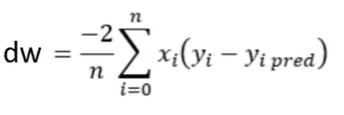

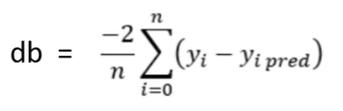

In [19]:
import numpy as np

**Linear Regression** model creation

In [20]:
class Linear_Regression():

  def __init__(self, learning_rate, no_of_iterations):
    # initializing the hyperparameters
    self.learning_rate = learning_rate
    self.no_of_iterations = no_of_iterations

  def fit(self, X, Y):
    # no. of training examples & no. of features
    self.m, self.n = X.shape  # no. of rows & columns

    # Initiating weight & bias
    self.w = np.zeros(self.n)
    self.b = 0
    self.x = X # first column from the dataset
    self.y = Y # second column from the dataset

    # implementing gradient descent
    for i in range(self.no_of_iterations):
      self.update_weights()


  def update_weights(self):
    yprediction = self.predict(self.x)

    # calculate the gradients
    dw = - (2 * (self.x.T).dot(self.y - yprediction)) // self.m

    db = - 2 * np.sum(self.y - yprediction) // self.m

    # updating the weights

    self.w = self.w - self.learning_rate * dw
    self.b = self.b - self.learning_rate * db

  def predict(self, X):
    return X.dot(self.w)+self.b  # this line is wX + b just simply written as Xw + b and returned to update_weights function to store this into Y. Therefore it becomes Y = wX+b

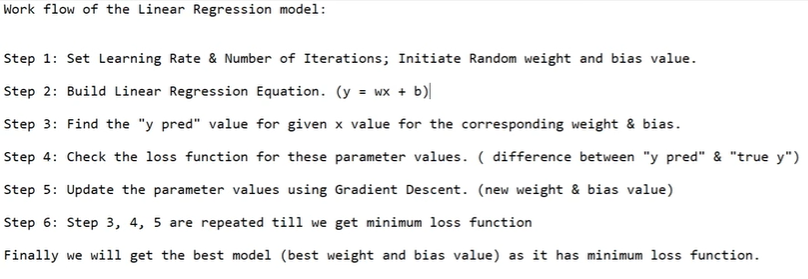

Using the created model :


In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

%matplotlib inline


In [22]:
df = pd.read_csv('/content/salary_data.csv')
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [23]:
df.shape

(30, 2)

In [24]:
# checking missing values / NULL values
df.isnull().sum()

,0
YearsExperience,0
Salary,0


In [25]:
# seperating features and target

x = df.iloc[:, : -1].values
y = df.iloc[:, 1].values

In [26]:
print(x)

[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]]


In [27]:
print(y)

[ 39343  46205  37731  43525  39891  56642  60150  54445  64445  57189
  63218  55794  56957  57081  61111  67938  66029  83088  81363  93940
  91738  98273 101302 113812 109431 105582 116969 112635 122391 121872]


In [28]:
# splitting into training and testing data

xtrain,xtest, ytrain,ytest = train_test_split(x,y,test_size=0.33, random_state=2)
print(x.shape,xtrain.shape,xtest.shape)

(30, 1) (20, 1) (10, 1)


In [29]:
# training the model
model = Linear_Regression(0.02,1000)


In [30]:
model.fit(xtrain,ytrain)

In [31]:
print('weight :',model.w)
print('bias :',model.b)

weight : [9514.26]
bias : 23698.480000000003


now we can do y = wX + b

for x number of experience what will be the salary that is y.

so to get salary, then the equation works as :

y = 9514*experience + 23697

In [32]:
test_data_prediction = model.predict(xtest)
print(test_data_prediction)

[ 36067.018  34164.166  66512.65   58901.242  91249.726  80784.04
 101715.412  52241.26   42727.     88395.448]


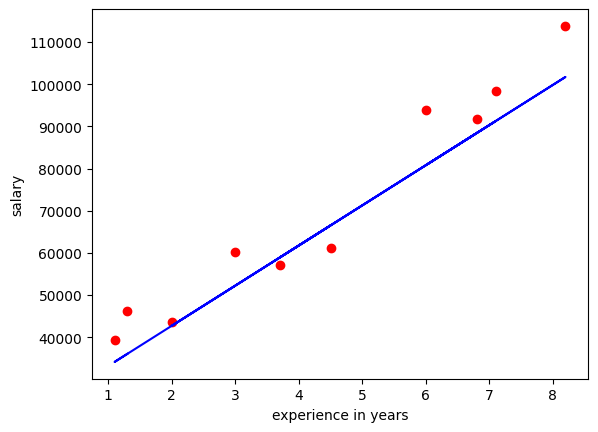

In [34]:
plt.scatter(xtest,ytest, color='red')
plt.plot(xtest,test_data_prediction, color='blue')
plt.xlabel('experience in years')
plt.ylabel('salary')
plt.show()